<a href="https://colab.research.google.com/github/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes/blob/dataset-3-experiment-3/notebooks/CDC_brfss_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CDC BRFSS Experiments 1-3

## Experiments

### Experiment 1: Baseline Algorithm Comparison
Train Logistic Regression, LightGBM, and XGBoost on raw, unbalanced CDC data.

### Experiment 2: Class Imbalance Handling
Compare:
- No resampling
- SMOTE
- Class weighting

### Experiment 3: Feature Importance Analysis
Tune LightGBM and XGBoost, then compare feature importance.


In [1]:
# 1 imports
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print("imports successfully loaded")

imports successfully loaded


In [2]:
# 2 clone repo / move into project folder
if not os.path.exists("/content/Predicting-Type-2-Diabetes"):
    !git clone https://github.com/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes.git

%cd /content/Predicting-Type-2-Diabetes

Cloning into 'Predicting-Type-2-Diabetes'...
remote: Enumerating objects: 543, done.
remote: Counting objects: 100% (215/215), done.
remote: Compressing objects: 100% (184/184), done.
remote: Total 543 (delta 127), reused 37 (delta 31), pack-reused 328 (from 1)
Receiving objects: 100% (543/543), 10.62 MiB | 8.83 MiB/s, done.
Resolving deltas: 100% (257/257), done.
/content/Predicting-Type-2-Diabetes


In [3]:
# 3 install dependencies
!pip install pyarrow lightgbm xgboost imbalanced-learn -q

print("dependencies ready")

dependencies ready


In [4]:
# 4 load CDC BRFSS data using Parquet

raw_dir = "data/raw"
csv_path = f"{raw_dir}/diabetes_binary_health_indicators_BRFSS2015.csv"
parquet_path = f"{raw_dir}/diabetes_binary_health_indicators_BRFSS2015.parquet"

if os.path.exists(parquet_path):
    df = pd.read_parquet(parquet_path)
    print("Loaded CDC data from Parquet.")

elif os.path.exists(csv_path):
    print("Parquet file not found, but CSV exists. Converting CSV to Parquet...")
    df = pd.read_csv(csv_path)
    df.to_parquet(parquet_path, index=False, compression="zstd")
    print("Converted and loaded CDC data from CSV.")

else:
    raise FileNotFoundError(
        "CDC dataset not found. Add diabetes_binary_health_indicators_BRFSS2015.parquet to data/raw/."
    )

print("Shape:", df.shape)
display(df.head())

Parquet file not found, but CSV exists. Converting CSV to Parquet...
Converted and loaded CDC data from CSV.
Shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
# 5 prepare split used across all experiments

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scale only for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE data for Experiment 2 and 3
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_train_scaled_smote, y_train_scaled_smote = smote.fit_resample(X_train_scaled, y_train)

# XGBoost class-weighting value
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print("-" * 50)
print(" CDC BRFSS Data Ready")
print("-" * 50)
print("Original shape:", df.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nOriginal target balance (%):")
print((y.value_counts(normalize=True) * 100).round(2))
print("\nSMOTE training balance:")
print(pd.Series(y_train_smote).value_counts())
print(f"\nXGBoost scale_pos_weight: {scale_pos_weight:.2f}")

--------------------------------------------------
 CDC BRFSS Data Ready
--------------------------------------------------
Original shape: (253680, 22)
Train shape: (202944, 21)
Test shape: (50736, 21)

Original target balance (%):
Diabetes_binary
0.0    86.07
1.0    13.93
Name: proportion, dtype: float64

SMOTE training balance:
Diabetes_binary
0.0    174667
1.0    174667
Name: count, dtype: int64

XGBoost scale_pos_weight: 6.18


In [6]:
# 6 helper functions

def evaluate_predictions(strategy, model_name, y_true, y_pred, y_prob):
    return {
        "Experiment": strategy,
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_true, y_prob)
    }


def evaluate_model(strategy, model_name, model, X_eval, y_true):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    metrics = evaluate_predictions(strategy, model_name, y_true, y_pred, y_prob)

    return metrics, y_pred, y_prob


def show_results_table(results, title):
    df_results = pd.DataFrame(results)
    print("-" * 70)
    print(title)
    print("-" * 70)
    display(df_results.round(4))
    return df_results

print("helper functions ready")

helper functions ready


# Experiment 1 — Baseline Algorithm Comparison

Raw, unbalanced CDC data.


In [7]:
# 7 experiment 1: train baseline models
print("-" * 50)
print(" Experiment 1: Training Raw Baseline Models")
print("-" * 50)

# Logistic Regression
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)
print("  Logistic Regression — done")

# LightGBM
lgbm_baseline = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm_baseline.fit(X_train, y_train)
print("  LightGBM            — done")

# XGBoost
xgb_baseline = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_baseline.fit(X_train, y_train)
print("  XGBoost             — done")

print("\nAll Experiment 1 models trained.")

--------------------------------------------------
 Experiment 1: Training Raw Baseline Models
--------------------------------------------------
  Logistic Regression — done
  LightGBM            — done
  XGBoost             — done

All Experiment 1 models trained.


In [8]:
# 8 experiment 1: evaluate baseline models
exp1_models = {
    "Logistic Regression": (lr_baseline, X_test_scaled),
    "LightGBM": (lgbm_baseline, X_test),
    "XGBoost": (xgb_baseline, X_test)
}

exp1_results = []
exp1_predictions = {}

for name, (model, X_eval) in exp1_models.items():
    metrics, y_pred, y_prob = evaluate_model("Experiment 1 - Raw Baseline", name, model, X_eval, y_test)
    exp1_results.append(metrics)
    exp1_predictions[name] = {"y_pred": y_pred, "y_prob": y_prob}

exp1_df = show_results_table(exp1_results, "Experiment 1 - CDC Raw Baseline Comparison")

----------------------------------------------------------------------
Experiment 1 - CDC Raw Baseline Comparison
----------------------------------------------------------------------


,Experiment,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Experiment 1 - Raw Baseline,Logistic Regression,0.8621,0.5171,0.1583,0.2424,0.8192
1,Experiment 1 - Raw Baseline,LightGBM,0.8655,0.5591,0.1640,0.2536,0.8269
2,Experiment 1 - Raw Baseline,XGBoost,0.8634,0.5309,0.1665,0.2535,0.8237


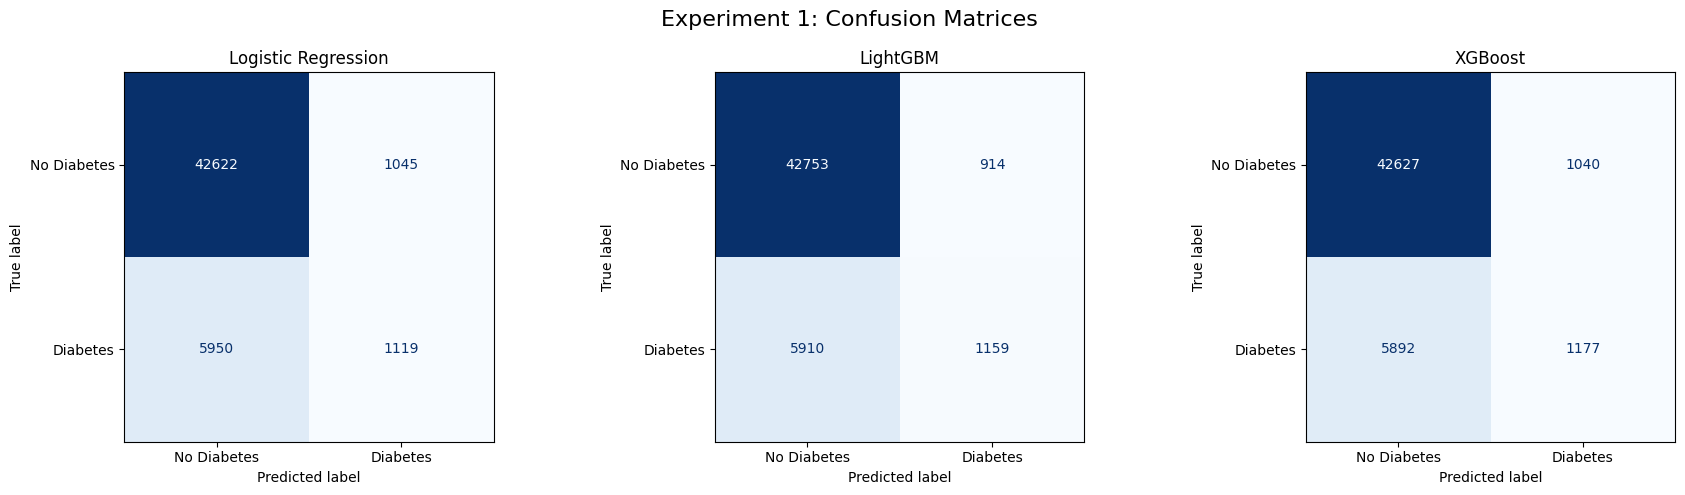

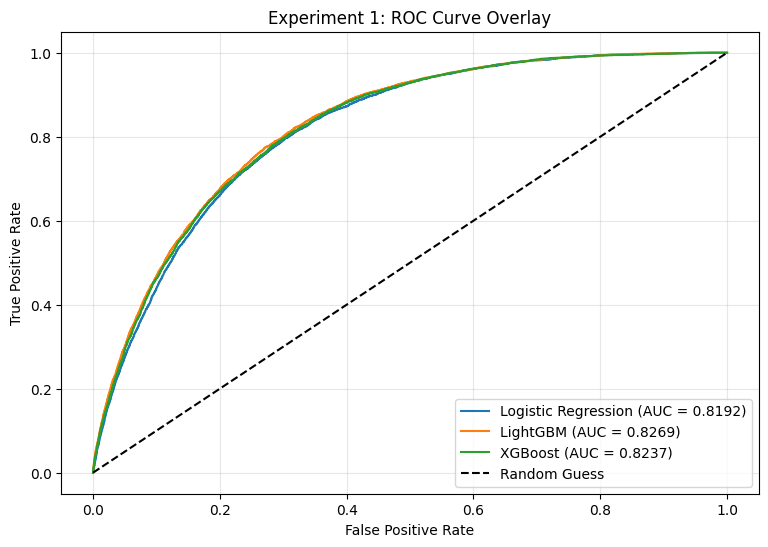

In [9]:
# 9 experiment 1: confusion matrices and ROC curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, preds) in enumerate(exp1_predictions.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(name)

plt.suptitle("Experiment 1: Confusion Matrices", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

for name, preds in exp1_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_prob"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Experiment 1: ROC Curve Overlay")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

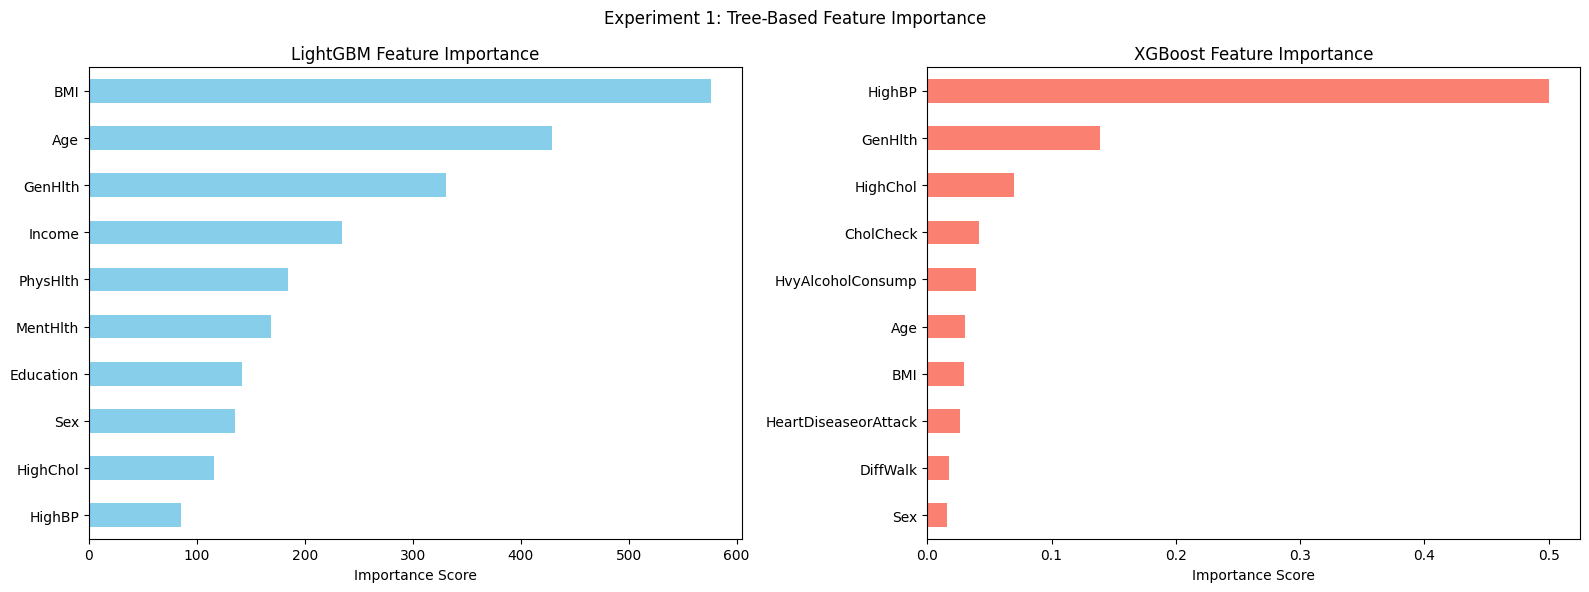

In [10]:
# 10 experiment 1: tree feature importance only
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

lgbm_importances = pd.Series(lgbm_baseline.feature_importances_, index=X.columns).sort_values(ascending=True)
lgbm_importances.tail(10).plot(kind="barh", ax=axes[0], color="skyblue")
axes[0].set_title("LightGBM Feature Importance")
axes[0].set_xlabel("Importance Score")

xgb_importances = pd.Series(xgb_baseline.feature_importances_, index=X.columns).sort_values(ascending=True)
xgb_importances.tail(10).plot(kind="barh", ax=axes[1], color="salmon")
axes[1].set_title("XGBoost Feature Importance")
axes[1].set_xlabel("Importance Score")

plt.suptitle("Experiment 1: Tree-Based Feature Importance")
plt.tight_layout()
plt.show()

In [11]:
# 11 experiment 1: short finding
best_f1 = exp1_df.sort_values("F1 Score", ascending=False).iloc[0]
best_auc = exp1_df.sort_values("AUC-ROC", ascending=False).iloc[0]

print("Experiment 1 Finding")
print("-" * 35)
print(f"Best model by F1 Score: {best_f1['Model']} ({best_f1['F1 Score']:.4f})")
print(f"Best model by AUC-ROC : {best_auc['Model']} ({best_auc['AUC-ROC']:.4f})")
print("\nThis is the raw, imbalanced baseline used for comparison in Experiment 2.")

Experiment 1 Finding
-----------------------------------
Best model by F1 Score: LightGBM (0.2536)
Best model by AUC-ROC : LightGBM (0.8269)

This is the raw, imbalanced baseline used for comparison in Experiment 2.


# Experiment 2 — Class Imbalance Handling

Compare three strategies:

1. No resampling  
2. SMOTE  
3. Class weighting  

Main focus:
- Recall
- F1 Score


In [12]:
# 12 experiment 2: train no resampling models
# These are the same idea as Experiment 1, but kept here for clean comparison.

print("-" * 50)
print(" Experiment 2 Strategy 1: No Resampling")
print("-" * 50)

lr_raw = LogisticRegression(max_iter=1000, random_state=42)
lr_raw.fit(X_train_scaled, y_train)

lgbm_raw = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm_raw.fit(X_train, y_train)

xgb_raw = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_raw.fit(X_train, y_train)

print("No resampling models trained.")

--------------------------------------------------
 Experiment 2 Strategy 1: No Resampling
--------------------------------------------------
No resampling models trained.


In [13]:
# 13 experiment 2: train SMOTE models
print("-" * 50)
print(" Experiment 2 Strategy 2: SMOTE")
print("-" * 50)

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_scaled_smote, y_train_scaled_smote)

lgbm_smote = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm_smote.fit(X_train_smote, y_train_smote)

xgb_smote = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_smote.fit(X_train_smote, y_train_smote)

print("SMOTE models trained.")

--------------------------------------------------
 Experiment 2 Strategy 2: SMOTE
--------------------------------------------------
SMOTE models trained.


In [14]:
# 14 experiment 2: train class weighted models
print("-" * 50)
print(" Experiment 2 Strategy 3: Class Weighting")
print("-" * 50)

lr_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_weighted.fit(X_train_scaled, y_train)

lgbm_weighted = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbosity=-1,
    class_weight="balanced"
)
lgbm_weighted.fit(X_train, y_train)

xgb_weighted = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)
xgb_weighted.fit(X_train, y_train)

print("Class weighted models trained.")

--------------------------------------------------
 Experiment 2 Strategy 3: Class Weighting
--------------------------------------------------
Class weighted models trained.


In [15]:
# 15 experiment 2: evaluate all imbalance strategies

exp2_models = {
    ("No Resampling", "Logistic Regression"): (lr_raw, X_test_scaled),
    ("No Resampling", "LightGBM"): (lgbm_raw, X_test),
    ("No Resampling", "XGBoost"): (xgb_raw, X_test),

    ("SMOTE", "Logistic Regression"): (lr_smote, X_test_scaled),
    ("SMOTE", "LightGBM"): (lgbm_smote, X_test),
    ("SMOTE", "XGBoost"): (xgb_smote, X_test),

    ("Class Weighting", "Logistic Regression"): (lr_weighted, X_test_scaled),
    ("Class Weighting", "LightGBM"): (lgbm_weighted, X_test),
    ("Class Weighting", "XGBoost"): (xgb_weighted, X_test),
}

exp2_results = []
exp2_predictions = {}

for (strategy, name), (model, X_eval) in exp2_models.items():
    metrics, y_pred, y_prob = evaluate_model(strategy, name, model, X_eval, y_test)
    exp2_results.append(metrics)
    exp2_predictions[(strategy, name)] = {"y_pred": y_pred, "y_prob": y_prob}

exp2_df = pd.DataFrame(exp2_results)

print("-" * 70)
print("Experiment 2 - CDC Imbalance Strategy Comparison")
print("-" * 70)
display(exp2_df.round(4).sort_values(by=["F1 Score", "Recall"], ascending=False))

----------------------------------------------------------------------
Experiment 2 - CDC Imbalance Strategy Comparison
----------------------------------------------------------------------


,Experiment,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
3,SMOTE,Logistic Regression,0.7331,0.3122,0.7614,0.4429,0.8188
8,Class Weighting,XGBoost,0.7284,0.3100,0.7745,0.4428,0.8218
6,Class Weighting,Logistic Regression,0.7315,0.3107,0.7611,0.4413,0.8196
7,Class Weighting,LightGBM,0.7203,0.3056,0.7915,0.4409,0.8267
4,SMOTE,LightGBM,0.8630,0.5212,0.2067,0.2960,0.8235
5,SMOTE,XGBoost,0.8640,0.5342,0.1856,0.2755,0.8231
1,No Resampling,LightGBM,0.8655,0.5591,0.1640,0.2536,0.8269
2,No Resampling,XGBoost,0.8634,0.5309,0.1665,0.2535,0.8237
0,No Resampling,Logistic Regression,0.8621,0.5171,0.1583,0.2424,0.8192


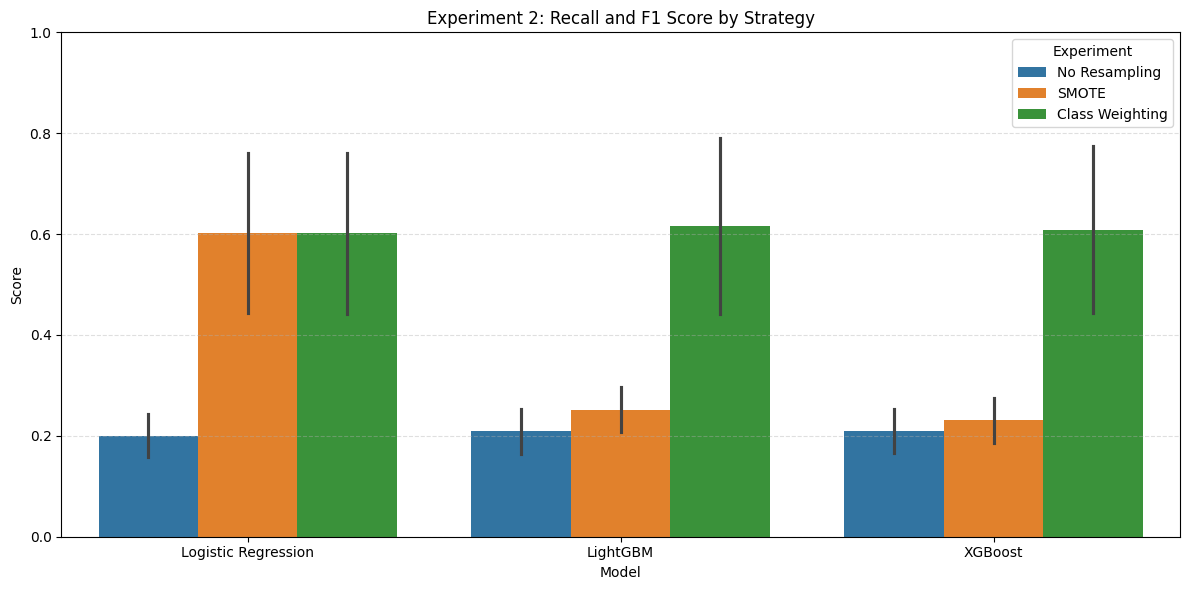

In [16]:
# 16 experiment 2: recall and F1 comparison
plot_df = exp2_df.melt(
    id_vars=["Experiment", "Model"],
    value_vars=["Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Experiment")
plt.title("Experiment 2: Recall and F1 Score by Strategy")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

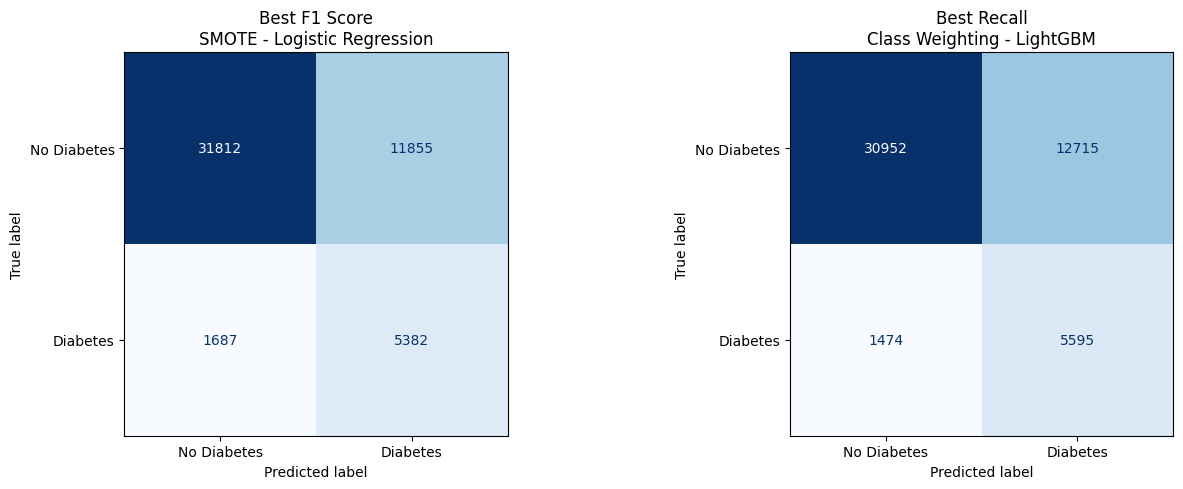

In [17]:
# 17 experiment 2: confusion matrices for best F1 and best Recall
best_f1_row = exp2_df.sort_values("F1 Score", ascending=False).iloc[0]
best_recall_row = exp2_df.sort_values("Recall", ascending=False).iloc[0]

best_cases = [
    ("Best F1 Score", best_f1_row),
    ("Best Recall", best_recall_row)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (title, row) in enumerate(best_cases):
    key = (row["Experiment"], row["Model"])
    y_pred = exp2_predictions[key]["y_pred"]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(f"{title}\n{row['Experiment']} - {row['Model']}")

plt.tight_layout()
plt.show()

In [18]:
# 18 experiment 2: short finding
best_f1 = exp2_df.sort_values("F1 Score", ascending=False).iloc[0]
best_recall = exp2_df.sort_values("Recall", ascending=False).iloc[0]

print("Experiment 2 Finding")
print("-" * 40)
print(f"Best by F1 Score: {best_f1['Experiment']} - {best_f1['Model']} ({best_f1['F1 Score']:.4f})")
print(f"Best by Recall  : {best_recall['Experiment']} - {best_recall['Model']} ({best_recall['Recall']:.4f})")
print("\nHigher recall means the model catches more diabetic cases.")
print("Higher F1 means a better balance between recall and precision.")

Experiment 2 Finding
----------------------------------------
Best by F1 Score: SMOTE - Logistic Regression (0.4429)
Best by Recall  : Class Weighting - LightGBM (0.7915)

Higher recall means the model catches more diabetic cases.
Higher F1 means a better balance between recall and precision.


# Experiment 3 — Feature Importance Analysis

Tune LightGBM and XGBoost, then compare feature importance.

For CDC BRFSS, there is no HbA1c or Glucose feature.  
So this dataset focuses on health, lifestyle, demographic, and healthcare access features.


In [19]:
# 19 experiment 3: create tuning sample
tuning_sample_size = min(60000, len(X_train_smote))

X_tune, _, y_tune, _ = train_test_split(
    X_train_smote,
    y_train_smote,
    train_size=tuning_sample_size,
    random_state=42,
    stratify=y_train_smote
)

print("Tuning sample shape:", X_tune.shape)
print("Tuning target balance:")
print(pd.Series(y_tune).value_counts())

Tuning sample shape: (60000, 21)
Tuning target balance:
Diabetes_binary
1.0    30000
0.0    30000
Name: count, dtype: int64


In [20]:
# 20 experiment 3: tune LightGBM
print("-" * 50)
print(" Experiment 3: Tuning LightGBM")
print("-" * 50)

lgbm_base = LGBMClassifier(random_state=42, verbosity=-1)

lgbm_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=lgbm_param_grid,
    n_iter=6,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_tune, y_tune)

print("Best LightGBM parameters:")
print(lgbm_search.best_params_)
print("\nBest LightGBM CV F1 Score:")
print(round(lgbm_search.best_score_, 4))

--------------------------------------------------
 Experiment 3: Tuning LightGBM
--------------------------------------------------
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best LightGBM parameters:
{'num_leaves': 31, 'n_estimators': 200, 'max_depth': -1, 'learning_rate': 0.05}

Best LightGBM CV F1 Score:
0.9119


In [21]:
# 21 experiment 3: train final tuned LightGBM
best_lgbm = LGBMClassifier(
    **lgbm_search.best_params_,
    random_state=42,
    verbosity=-1
)

best_lgbm.fit(X_train_smote, y_train_smote)

lgbm_tuned_metrics, lgbm_tuned_pred, lgbm_tuned_prob = evaluate_model(
    "Experiment 3 - Tuned",
    "Tuned LightGBM",
    best_lgbm,
    X_test,
    y_test
)

print("Tuned LightGBM evaluated.")
print(classification_report(y_test, lgbm_tuned_pred, zero_division=0))

Tuned LightGBM evaluated.
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.52      0.20      0.29      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.59      0.61     50736
weighted avg       0.83      0.86      0.84     50736



In [22]:
# 22 experiment 3: tune XGBoost
print("-" * 50)
print(" Experiment 3: Tuning XGBoost")
print("-" * 50)

xgb_base = XGBClassifier(random_state=42, eval_metric="logloss")

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=6,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_tune, y_tune)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)
print("\nBest XGBoost CV F1 Score:")
print(round(xgb_search.best_score_, 4))

--------------------------------------------------
 Experiment 3: Tuning XGBoost
--------------------------------------------------
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best XGBoost parameters:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best XGBoost CV F1 Score:
0.9085


In [23]:
# 23 experiment 3: train final tuned XGBoost
best_xgb = XGBClassifier(
    **xgb_search.best_params_,
    random_state=42,
    eval_metric="logloss"
)

best_xgb.fit(X_train_smote, y_train_smote)

xgb_tuned_metrics, xgb_tuned_pred, xgb_tuned_prob = evaluate_model(
    "Experiment 3 - Tuned",
    "Tuned XGBoost",
    best_xgb,
    X_test,
    y_test
)

print("Tuned XGBoost evaluated.")
print(classification_report(y_test, xgb_tuned_pred, zero_division=0))

Tuned XGBoost evaluated.
              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92     43667
         1.0       0.52      0.23      0.32      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.60      0.62     50736
weighted avg       0.83      0.86      0.84     50736



In [24]:
# 24 experiment 3: tuned model comparison
exp3_df = pd.DataFrame([lgbm_tuned_metrics, xgb_tuned_metrics])

print("-" * 60)
print("Experiment 3 - Tuned Model Comparison")
print("-" * 60)
display(exp3_df.round(4))

------------------------------------------------------------
Experiment 3 - Tuned Model Comparison
------------------------------------------------------------


,Experiment,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Experiment 3 - Tuned,Tuned LightGBM,0.8631,0.5226,0.2046,0.2940,0.8234
1,Experiment 3 - Tuned,Tuned XGBoost,0.8626,0.5151,0.2316,0.3195,0.8219


In [25]:
# 25 experiment 3: extract feature importance
lgbm_importance = pd.DataFrame({
    "Feature": X.columns,
    "LightGBM Importance": best_lgbm.feature_importances_
})

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "XGBoost Importance": best_xgb.feature_importances_
})

lgbm_importance["LightGBM Normalized"] = (
    lgbm_importance["LightGBM Importance"] / lgbm_importance["LightGBM Importance"].sum()
)

xgb_importance["XGBoost Normalized"] = (
    xgb_importance["XGBoost Importance"] / xgb_importance["XGBoost Importance"].sum()
)

importance_df = pd.merge(lgbm_importance, xgb_importance, on="Feature")

importance_df["Average Importance"] = (
    importance_df["LightGBM Normalized"] +
    importance_df["XGBoost Normalized"]
) / 2

importance_df = importance_df.sort_values("Average Importance", ascending=False)

display(importance_df.head(10))

,Feature,LightGBM Importance,LightGBM Normalized,XGBoost Importance,XGBoost Normalized,Average Importance
13,GenHlth,892,0.148667,0.053071,0.053071,0.100869
0,HighBP,302,0.050333,0.150671,0.150671,0.100502
18,Age,977,0.162833,0.024872,0.024872,0.093853
3,BMI,779,0.129833,0.021156,0.021156,0.075495
8,Fruits,135,0.022500,0.105691,0.105691,0.064095
1,HighChol,295,0.049167,0.076421,0.076421,0.062794
17,Sex,303,0.050500,0.061269,0.061269,0.055884
4,Smoker,174,0.029000,0.074114,0.074114,0.051557
7,PhysActivity,116,0.019333,0.069994,0.069994,0.044664
10,HvyAlcoholConsump,145,0.024167,0.063692,0.063692,0.043929


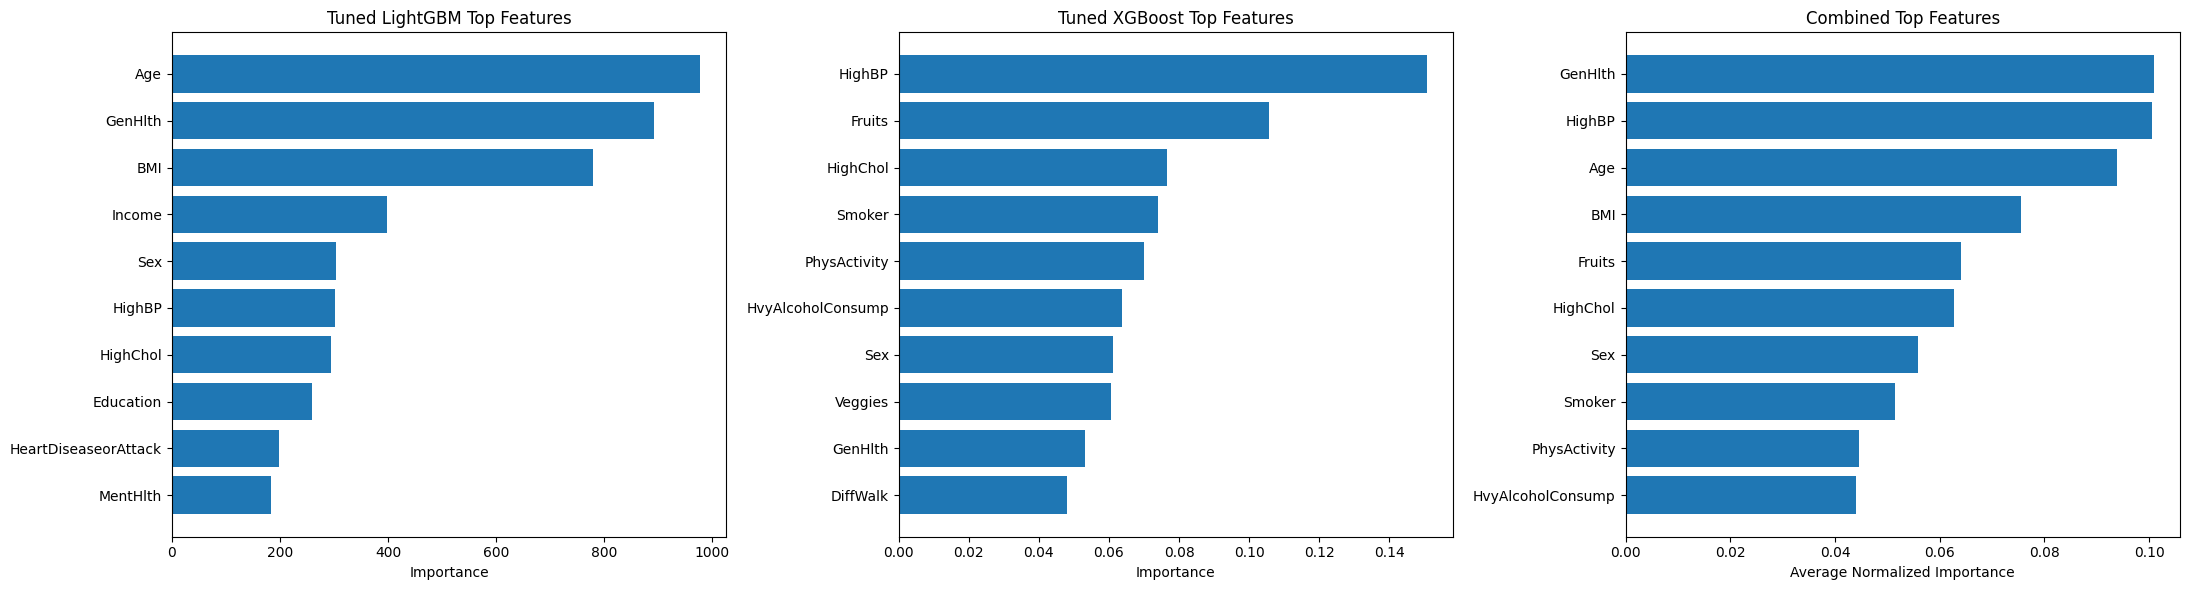

In [26]:
# 26 experiment 3: plot feature importance
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

top_lgbm = lgbm_importance.sort_values("LightGBM Importance", ascending=True).tail(10)
axes[0].barh(top_lgbm["Feature"], top_lgbm["LightGBM Importance"])
axes[0].set_title("Tuned LightGBM Top Features")
axes[0].set_xlabel("Importance")

top_xgb = xgb_importance.sort_values("XGBoost Importance", ascending=True).tail(10)
axes[1].barh(top_xgb["Feature"], top_xgb["XGBoost Importance"])
axes[1].set_title("Tuned XGBoost Top Features")
axes[1].set_xlabel("Importance")

top_combined = importance_df.sort_values("Average Importance", ascending=True).tail(10)
axes[2].barh(top_combined["Feature"], top_combined["Average Importance"])
axes[2].set_title("Combined Top Features")
axes[2].set_xlabel("Average Normalized Importance")

plt.tight_layout()
plt.show()

,Feature Group,Average Importance
0,Health Indicators,0.587853
1,Lifestyle,0.247554
2,Demographic / Socioeconomic,0.138192
3,Healthcare Access,0.026400


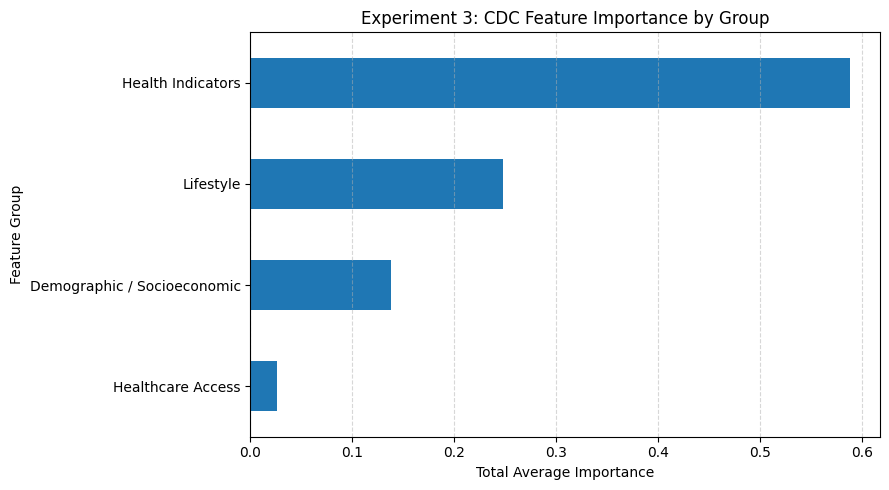

In [27]:
# 27 experiment 3: group feature importance
feature_groups = {
    "Health Indicators": [
        "HighBP", "HighChol", "CholCheck", "BMI", "Stroke",
        "HeartDiseaseorAttack", "GenHlth", "MentHlth",
        "PhysHlth", "DiffWalk", "Age"
    ],
    "Lifestyle": [
        "Smoker", "PhysActivity", "Fruits", "Veggies",
        "HvyAlcoholConsump"
    ],
    "Healthcare Access": [
        "AnyHealthcare", "NoDocbcCost"
    ],
    "Demographic / Socioeconomic": [
        "Sex", "Education", "Income"
    ]
}

def assign_group(feature):
    for group, features in feature_groups.items():
        if feature in features:
            return group
    return "Other"

importance_df["Feature Group"] = importance_df["Feature"].apply(assign_group)

group_importance = (
    importance_df.groupby("Feature Group")["Average Importance"]
    .sum()
    .sort_values(ascending=False)
)

display(group_importance.reset_index())

plt.figure(figsize=(9, 5))
group_importance.sort_values(ascending=True).plot(kind="barh")
plt.title("Experiment 3: CDC Feature Importance by Group")
plt.xlabel("Total Average Importance")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [28]:
# 28 save all summary outputs
os.makedirs("results", exist_ok=True)

exp1_df.to_csv("results/cdc_experiment_1_baseline_results.csv", index=False)
exp2_df.to_csv("results/cdc_experiment_2_imbalance_results.csv", index=False)
exp3_df.to_csv("results/cdc_experiment_3_tuned_results.csv", index=False)
importance_df.to_csv("results/cdc_experiment_3_feature_importance.csv", index=False)

# parquet versions are also saved
exp1_df.to_parquet("results/cdc_experiment_1_baseline_results.parquet", index=False)
exp2_df.to_parquet("results/cdc_experiment_2_imbalance_results.parquet", index=False)
exp3_df.to_parquet("results/cdc_experiment_3_tuned_results.parquet", index=False)
importance_df.to_parquet("results/cdc_experiment_3_feature_importance.parquet", index=False)

print("All CDC experiment results saved to results/.")

All CDC experiment results saved to results/.


In [29]:
# 29 final summary
print("Final CDC Experiment Summary")
print("-" * 45)

exp1_best = exp1_df.sort_values("F1 Score", ascending=False).iloc[0]
exp2_best_f1 = exp2_df.sort_values("F1 Score", ascending=False).iloc[0]
exp2_best_recall = exp2_df.sort_values("Recall", ascending=False).iloc[0]
exp3_best = exp3_df.sort_values("F1 Score", ascending=False).iloc[0]

print(f"Experiment 1 best baseline by F1: {exp1_best['Model']} ({exp1_best['F1 Score']:.4f})")
print(f"Experiment 2 best by F1: {exp2_best_f1['Experiment']} - {exp2_best_f1['Model']} ({exp2_best_f1['F1 Score']:.4f})")
print(f"Experiment 2 best by Recall: {exp2_best_recall['Experiment']} - {exp2_best_recall['Model']} ({exp2_best_recall['Recall']:.4f})")
print(f"Experiment 3 best tuned model by F1: {exp3_best['Model']} ({exp3_best['F1 Score']:.4f})")

print("\nTop 5 CDC features from tuned tree models:")
for feature in importance_df.head(5)["Feature"].tolist():
    print(f"- {feature}")

print("\nNote: CDC BRFSS does not contain HbA1c or Glucose, so feature importance is based on survey health/lifestyle indicators.")

Final CDC Experiment Summary
---------------------------------------------
Experiment 1 best baseline by F1: LightGBM (0.2536)
Experiment 2 best by F1: SMOTE - Logistic Regression (0.4429)
Experiment 2 best by Recall: Class Weighting - LightGBM (0.7915)
Experiment 3 best tuned model by F1: Tuned XGBoost (0.3195)

Top 5 CDC features from tuned tree models:
- GenHlth
- HighBP
- Age
- BMI
- Fruits

Note: CDC BRFSS does not contain HbA1c or Glucose, so feature importance is based on survey health/lifestyle indicators.
